<a href="https://colab.research.google.com/github/braltoids0089/AGRO-BIOTECHNOLOGY/blob/main/L3_SmartMatrix_Bayesian%2BOptimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartMatrix R&D Accelerator · Notebook 3 of 3 · **v2**
## Layer 3 — Algorithmic optimisation: Pareto efficiency and strain discovery against RSM *as practised*

> **Post-run note.** The question as originally posed was *"does Bayesian Optimisation reach the target in fewer experiments than RSM as practised?"* That question and its predictions are kept unchanged below. The answer for single-target speed turned out to be **no** (BO and sequential RSM tied). The supported claims are Pareto-front coverage (about 2× sequential RSM) and discovery of never-fermented strains. The title reflects those; the revised hypotheses H3a, H3b and H4 are stated in Section 8.

**H3 (experimental efficiency).** At a matched budget, batch constrained multi-objective BO reaches a pre-specified target region in fewer runs than Response Surface Methodology, and attains a higher dominated hypervolume.

### v1 record (pre-registered, kept unchanged; 20 campaigns per arm)
| Arm | Target hit rate | Median runs to target | Median HV at 48 runs |
|---|---|---|---|
| BO (qLogNEHVI) | 20/20 | 17 | 1.01 |
| CCD-RSM, single stage | 1/20 | censored at 48 | 0.53 |
| Sobol | 12/20 | 38.5 | 0.43 |

All v1 checks passed (log-rank and Mann–Whitney p < 10⁻⁴). Two credibility problems remained:
1. **A single CCD over the full box is close to a straw man.** Its points sit on corners and faces, while the feasible region is interior (15% of the space). No experienced practitioner runs RSM that way.
2. **The hypervolume reference was beaten** (BO median 1.01 of "best achievable"): a random sample does not reach the true Pareto front.

Part B also had a design gap: every strain was fermented during initialisation, so it tested BO, not the value of genomic information (Layer 2 showed genome ≈ one-hot for *seen* strains).

### What changed in v2
| Change | Addresses |
|---|---|
| New arm: **sequential RSM** (screening fraction → steepest ascent → local CCD → confirmation), same 48-run budget | 1 |
| Reference front from Monte Carlo **plus local refinement** on the noise-free simulator | 2 |
| Part B redesigned: the two truly best strains are **never fermented at the start**; arms compare block-Hamming, whole-genome and one-hot kernels against random strain choice | Part B gap |
| Exact p-values; runtime estimate after the first campaign | presentation |

Lot `L2` is identical to v1, so Part A's ground truth, thresholds and reference point are unchanged.

### Predictions, stated before running
| ID | Prediction |
|---|---|
| P1 | Sequential RSM clearly beats single-stage CCD, but BO still reaches the target faster than sequential RSM (log-rank p < 0.05) |
| P2 | BO's hypervolume at 48 runs exceeds sequential RSM's (one-sided Mann–Whitney p < 0.05) |
| P3 | No campaign exceeds the refined reference front by more than 2% |
| P4 | Part B: block-Hamming BO first runs a hidden top-2 strain earlier (median) than one-hot BO |
| P5 | Part B: block-Hamming BO beats one-hot BO on final hypervolume in at least 4 of 5 seeds |

## 0 · Environment setup

Runs on **Google Colab** or **Kaggle** (a CPU runtime is sufficient; on Kaggle enable *Internet* in the notebook settings so `pip` can install packages). The cell installs only what is missing; package versions are printed at the end of the notebook for the record.

In [ ]:
import os, sys, subprocess, importlib.util, platform
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle')
def ensure(pkgs):
    missing = [pip for pip, mod in pkgs if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing], check=True)
ensure([('botorch', 'botorch'), ('gpytorch', 'gpytorch'), ('lifelines', 'lifelines')])
print('Runtime:', 'Colab' if IN_COLAB else 'Kaggle' if IN_KAGGLE else 'local', '| Python', platform.python_version())

Runtime: Colab | Python 3.13.15


In [ ]:
import warnings, time, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'font.size': 10})
PAL = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']
GLOBAL_SEED = 3031        # v2: fresh seed, so v2 is judged on data that did not motivate the changes
SMOKE = os.environ.get('SMARTMATRIX_SMOKE') == '1'   # developer switch: tiny loops for an end-to-end syntax run
rng = np.random.default_rng(GLOBAL_SEED)
T0 = time.time()
fmt_p = lambda p: f'{p:.2e}' if p < 1e-3 else f'{p:.3f}'
def show_scorecard(checks, title):
    sc = pd.DataFrame([(k, v[0] if isinstance(v[0], str) else round(float(v[0]), 3), 'PASS' if v[1] else 'FAIL')
                       for k, v in checks.items()], columns=['check', 'value', 'result'])
    print(title)
    with pd.option_context('display.max_colwidth', None): display(sc)
    return sc

## 1 · The virtual lab (ground-truth simulator, v2)

All three notebooks share one mechanistic simulator, written to `smartmatrix_sim.py`. It stands in for the wet lab so every computational claim can be **checked against a known truth**, which real data never allows.

* **Strains:** 16 synthetic strains, each a presence/absence vector over 32 genes in 8 functional modules (proteolysis; dextransucrase `dsrA` + EPS cluster; decarboxylases `hdcA/tdcA/odc`; GABA shunt `gadB/gadC`; dehydrogenases `adhE/adh2/aldA`; sugar utilisation; stress tolerance; 7 neutral background genes). Kinetic traits are *derived from* the genes.
* **Substrate lots (v2: 8, up from 4).** Lots L1–L4 are bit-identical to v1, so v1 results remain valid records; L5–L8 are new. With 4 lots, lot effects were unidentifiable in v1 (4 points in a 4-D composition space).
* **Kinetics:** cardinal-temperature growth (Rosso CTMI), Monod substrate limitation, Luedeking–Piret acid formation, pH-gated dextransucrase, lipid oxidation vs ADH-mediated hexanal reduction, acid-stimulated GAD, proteolysis-fed decarboxylation.
* **Phenotypes:** log₁₀ G′ (Pa), off-flavour index, GABA (mg/kg; exactly zero for strains without `gadB`), final pH, biogenic amines (mg/kg), with heteroscedastic noise and a lot random effect.
* **v2 additions:** `nominal_strain(misspecified=True)` with `ph_model='linear'` produces a deliberately *wrong* mechanistic prior, so gray-box gains can be tested under realistic model error.

> **Scope of the evidence.** The kinetic forms are literature-shaped but the parameter values are illustrative. These notebooks validate the *computational stack and protocol*, not the biology of any real strain.

In [ ]:
%%writefile smartmatrix_sim.py
# ============================================================
# SmartMatrix virtual lab (v2) — a mechanistic ground-truth simulator
# ============================================================
# Purpose: provide a KNOWN ground truth so every computational claim
# (mechanism recovery, surrogate accuracy, optimisation efficiency) can be
# checked against the truth. The kinetics are literature-shaped
# (cardinal-temperature growth, Monod substrate limitation,
# Luedeking–Piret acid formation, pH-gated enzyme activities) but the
# parameter values are illustrative, NOT fitted to any real strain.
import numpy as np
import pandas as pd

GENES = [
    # proteolytic system
    "prtP", "pepN", "pepC", "pepX", "pepO", "oppA",
    # EPS: dextransucrase + generic eps cluster
    "dsrA", "epsA", "epsB", "epsC",
    # amino-acid decarboxylases (biogenic amines)
    "hdcA", "tdcA", "odc",
    # GABA shunt
    "gadB", "gadC",
    # aldehyde/alcohol dehydrogenases (hexanal -> hexanol)
    "adhE", "adh2", "aldA",
    # carbohydrate utilisation (sucrose, raffinose-family oligosaccharides)
    "sacA", "scrB", "rafA", "galK",
    # acid / heat stress tolerance
    "clpL", "dnaK2", "atpD2",
    # neutral background genes (no phenotypic effect in the simulator)
    "bg01", "bg02", "bg03", "bg04", "bg05", "bg06", "bg07",
]
BLOCKS = {
    "protease": ["prtP", "pepN", "pepC", "pepX", "pepO", "oppA"],
    "eps": ["epsA", "epsB", "epsC"],
    "amine": ["hdcA", "tdcA", "odc"],
    "gaba": ["gadB", "gadC"],
    "adh": ["adhE", "adh2", "aldA"],
    "sugar": ["sacA", "scrB", "rafA", "galK"],
    "stress": ["clpL", "dnaK2", "atpD2"],
}

# Decision variables (bounds) — what the scientist sets before inoculation
DESIGN = {
    "faba_frac": (0.0, 1.0),     # faba : pea protein ratio (0 = all pea)
    "solids":    (8.0, 16.0),    # protein solids, % w/w
    "sucrose":   (0.0, 6.0),     # added sucrose, % w/w (dextran substrate)
    "temp":      (25.0, 42.0),   # incubation temperature, degC
    "time":      (8.0, 48.0),    # fermentation time, h
    "log_inoc":  (5.0, 8.0),     # inoculum, log10 CFU/mL
}
DVARS = list(DESIGN)
OUTCOMES = ["logG", "offflavor", "gaba", "pH", "amines"]
NOISE_SD = {"logG": 0.06, "offflavor": 0.04, "gaba_cv": 0.08, "pH": 0.03, "amines_cv": 0.10}


def make_strains(n=16, seed=7):
    """Binary gene presence/absence matrix + latent traits derived from genes."""
    rng = np.random.default_rng(seed)
    p = np.full(len(GENES), 0.5)
    G = (rng.random((n, len(GENES))) < p).astype(int)
    idx = {g: i for i, g in enumerate(GENES)}
    # enforce realistic diversity: a few EPS producers, a few GABA producers,
    # and a partial linkage between dextransucrase and histidine decarboxylase
    G[:, idx["dsrA"]] = 0
    G[[1, 4, 7, 10, 13], idx["dsrA"]] = 1
    G[:, idx["gadB"]] = 0
    G[[2, 4, 9, 11, 14], idx["gadB"]] = 1
    G[[1, 10], idx["hdcA"]] = 1
    G[[4, 13], idx["hdcA"]] = 0
    names = [f"S{i+1:02d}" for i in range(n)]
    genome = pd.DataFrame(G, index=names, columns=GENES)
    jit = pd.DataFrame(rng.normal(0, 1, (n, 2)), index=names, columns=["_j0", "_j1"])
    return genome, derive_traits(genome, jit)


def derive_traits(genome, jit):
    """Map gene content (+ fixed strain-specific jitter) to kinetic traits.
    Used both to build strains and to re-derive traits after an in-silico knockout."""
    m = lambda b: genome[BLOCKS[b]].mean(1).values
    traits = pd.DataFrame(index=genome.index)
    traits["mu_max"] = np.clip(0.28 + 0.25 * m("sugar") + 0.04 * jit["_j0"].values, 0.2, 0.7)   # 1/h
    traits["T_opt"] = np.clip(33 + 6 * m("stress") + 1.5 * jit["_j1"].values, 30, 41)          # degC
    traits["pH_min"] = np.clip(4.0 - 0.35 * m("stress"), 3.55, 4.1)
    traits["prot"] = 0.15 + 0.85 * m("protease")
    traits["eps_cap"] = genome["dsrA"].values * (0.8 + 0.4 * m("eps"))
    traits["gad"] = genome["gadB"].values * (0.5 + 0.5 * genome["gadC"].values)
    traits["amine"] = 0.65 * genome["hdcA"].values + 0.35 * genome["tdcA"].values + 0.15 * genome["odc"].values
    traits["adh"] = m("adh")
    traits["raf"] = genome["rafA"].values
    traits[["_j0", "_j1"]] = jit.values          # hidden jitter kept so knockouts are reproducible
    return traits


def make_lots(n=8, seed=11):
    """Substrate lot context. v2: 8 lots; L1-L4 are bit-identical to v1 (so v1 results stay valid
    records), L5-L8 are appended from an independent stream."""
    def _draw(k, sd):
        r = np.random.default_rng(sd)
        return pd.DataFrame({
            "lot_lipid": r.uniform(1.5, 4.0, k),       # % dry basis
            "lot_buffer": r.uniform(0.8, 1.25, k),     # relative buffering capacity
            "lot_glu": r.uniform(0.7, 1.3, k),         # relative free glutamate
            "lot_rfo": r.uniform(3.0, 7.0, k),         # raffinose-family oligosaccharides, g/L
        })
    lots = _draw(4, seed)
    if n > 4:
        lots = pd.concat([lots, _draw(n - 4, seed + 1000)], ignore_index=True)
    lots = lots.iloc[:n].copy()
    lots.index = [f"L{i+1}" for i in range(n)]
    return lots


# Functional gene modules used by the block kernels (every gene belongs to exactly one block)
KERNEL_BLOCKS = {
    "protease": BLOCKS["protease"], "eps": ["dsrA"] + BLOCKS["eps"], "amine": BLOCKS["amine"],
    "gaba": BLOCKS["gaba"], "adh": BLOCKS["adh"], "sugar": BLOCKS["sugar"], "stress": BLOCKS["stress"],
    "background": [g for g in GENES if g.startswith("bg")],
}


def nominal_strain(strains, misspecified=False):
    """Population-average 'NOM' strain for a gray-box prior. misspecified=True perturbs the kinetic
    parameters by roughly +/-30% (as a literature-parameter model would be wrong) and the caller should
    also pass ph_model='linear' to simulate()."""
    genome, traits = strains
    t = traits.mean().to_frame("NOM").T
    if misspecified:
        t["mu_max"] *= 0.7; t["T_opt"] += 3.0; t["pH_min"] += 0.15
        t["prot"] *= 1.3; t["eps_cap"] *= 1.3; t["adh"] *= 0.7; t["gad"] *= 1.3; t["amine"] *= 0.7
    g = pd.DataFrame(np.zeros((1, len(GENES)), int), index=["NOM"], columns=GENES)
    return pd.concat([genome, g]), pd.concat([traits, t])


def _ctmi(T, Topt, Tmin=12.0, Tmax=46.0):
    """Rosso cardinal-temperature model (0..1)."""
    T = np.clip(T, Tmin + 1e-6, Tmax - 1e-6)
    num = (T - Tmax) * (T - Tmin) ** 2
    den = (Topt - Tmin) * ((Topt - Tmin) * (T - Topt) - (Topt - Tmax) * (Topt + Tmin - 2 * T))
    return np.clip(num / den, 0, 1)


def simulate(X, strain_ids, lot_ids, strains, lots, noise=True, seed=None,
             record_traj=False, dt=0.25, knockout=None, ph_model="full"):
    """Vectorised RK2 integration of the fermentation ODE for a batch of runs.

    X          : (n, 6) array in DVARS order, natural units
    strain_ids : length-n list of strain names
    lot_ids    : length-n list of lot names
    knockout   : optional gene name forced absent (in-silico perturbation)
    ph_model   : 'full' (true exponential buffering) or 'linear' (deliberately misspecified, for priors)
    Returns DataFrame of endpoint outcomes (+ optional trajectories).
    """
    genome, traits = strains
    X = np.atleast_2d(np.asarray(X, float))
    n = X.shape[0]
    tr = traits.loc[list(strain_ids)].copy()
    if knockout is not None:                     # in-silico gene deletion, propagated to all traits
        g = genome.loc[list(strain_ids)].reset_index(drop=True).copy(); g[knockout] = 0
        j = traits.loc[list(strain_ids), ["_j0", "_j1"]].reset_index(drop=True)
        tr = derive_traits(g, j)
    lt = lots.loc[list(lot_ids)]
    faba, sol, suc, T, tend, linoc = [X[:, i] for i in range(6)]
    mu, Topt, pHmin = tr.mu_max.values, tr.T_opt.values, tr.pH_min.values
    prot, epsc, gad, amn, adh, raf = (tr[c].values for c in ["prot", "eps_cap", "gad", "amine", "adh", "raf"])
    lip, buf, glu, rfo = (lt[c].values for c in ["lot_lipid", "lot_buffer", "lot_glu", "lot_rfo"])

    phiT = _ctmi(T, Topt)
    beta = 1.1 * (sol / 12.0) * buf                      # buffering (g/L acid per pH decade-ish)
    pH0 = 6.6 - 0.05 * (sol - 12)
    Xmax = 25.0 * (0.6 + 0.4 * sol / 12.0)               # relative biomass capacity
    # state: X biomass, Sn native sugar, Ss sucrose, P acid, E eps, H hexanal, F free AA, Gb gaba, A amines
    s = np.zeros((n, 9))
    s[:, 0] = 10 ** (linoc - 7.0)
    s[:, 1] = 2.0 + raf * rfo                            # RFOs only usable with rafA
    s[:, 2] = 10.0 * suc
    s[:, 5] = 2.0 + 1.6 * lip * (1.25 - 0.5 * faba)      # pea lipoxygenase -> more hexanal
    s[:, 6] = 0.5
    steps = int(np.ceil(DESIGN["time"][1] / dt))

    def ph_of(P):
        if ph_model == "linear":
            return np.maximum(3.6, pH0 - 0.4 * P / beta)
        return 3.4 + (pH0 - 3.4) * np.exp(-P / (6.0 * beta))
    traj = [] if record_traj else None

    def deriv(s):
        Xb, Sn, Ss, P, E, H, F, Gb, A = s.T
        pH = ph_of(P)
        fpH = np.clip((pH - pHmin) / (5.2 - pHmin), 0, 1)
        S = Sn + Ss
        fS = S / (0.8 + S)
        growth = mu * phiT * fpH * fS * Xb * (1 - Xb / Xmax)
        acid = 0.9 * growth + 0.03 * Xb * fpH * fS * phiT          # Luedeking–Piret
        wsn = Sn / (S + 1e-9)
        dSn = -(growth / 0.25 + acid) * wsn
        # dextransucrase: optimum ~pH 5.4, cooler temperatures, needs sucrose
        feps = np.exp(-((pH - 5.3) / 0.8) ** 2) * _ctmi(T, 28.0, 10.0, 44.0)
        eps = 0.5 * epsc * Xb * Ss / (4.0 + Ss) * feps
        dSs = -(growth / 0.25 + acid) * (1 - wsn) - 2.0 * eps
        ox = 0.02 * lip * np.exp(0.06 * (T - 30))                    # ongoing lipid oxidation
        dH = ox - 0.012 * adh * Xb * H * phiT
        dF = 0.05 * prot * Xb * phiT * (1 + 0.5 * (pH < 5.5))
        acidstim = 1 / (1 + np.exp((pH - 4.9) / 0.15))
        dG = 3.0 * gad * Xb * glu * (1 + 0.4 * F) * acidstim * 0.02
        dA = 0.9 * amn * Xb * F * (1 + acidstim) * 0.02
        return np.stack([growth, dSn, dSs, acid, eps, dH, dF, dG, dA], 1), pH

    tgrid = np.arange(steps + 1) * dt
    for k in range(steps):
        active = (tgrid[k] < tend)[:, None]
        d1, pH = deriv(s)
        d2, _ = deriv(np.maximum(s + dt * d1, 0))
        s = np.where(active, np.maximum(s + 0.5 * dt * (d1 + d2), 0), s)
        if record_traj and k % 4 == 0:
            traj.append((tgrid[k], s[:, 0].copy(), pH.copy()))
    Xb, Sn, Ss, P, E, H, F, Gb, A = s.T
    pH = ph_of(P)

    # --- endpoint phenotypes ---
    gel_pH = np.exp(-((pH - 4.7) / 0.45) ** 2)          # acid gelation near protein pI
    gel = (sol / 12.0) ** 2.2 * (0.75 + 0.5 * faba) * (0.15 + gel_pH)
    gel = gel * (1 - 0.45 * np.tanh(F / 6.0))            # proteolysis weakens network
    gel = gel + 1.0 * np.tanh(E / 5.0) * (sol / 12.0)    # dextran reinforces
    out = pd.DataFrame({
        "logG": np.log10(120 + 2600 * gel),              # log10 Pa
        "offflavor": np.log10(H + 0.3 * (1 - faba) + 0.2),
        "gaba": 800 * (1 - np.exp(-Gb / 12.0)),         # mg/kg (saturating)
        "pH": pH,
        "amines": 5 + 600 * (1 - np.exp(-A / 40.0)),    # mg/kg (saturating)
    })
    if noise:
        rng = np.random.default_rng(seed)
        lot_eff = {l: v for l, v in zip(lots.index, np.random.default_rng(99).normal(0, 0.04, len(lots)))}
        out["logG"] += rng.normal(0, NOISE_SD["logG"], n) + np.array([lot_eff[l] for l in lot_ids])
        out["offflavor"] += rng.normal(0, NOISE_SD["offflavor"], n)
        out["gaba"] *= np.exp(rng.normal(0, NOISE_SD["gaba_cv"], n))
        out["pH"] += rng.normal(0, NOISE_SD["pH"], n)
        out["amines"] *= np.exp(rng.normal(0, NOISE_SD["amines_cv"], n))
    if record_traj:
        return out, traj
    return out

Writing smartmatrix_sim.py


### 1.1 · Shared surrogate-model toolkit
Written to `smartmatrix_models.py` and shared by Layers 2 and 3: Matérn process kernels; four strain kernels (whole-genome Tanimoto, block-Tanimoto, block-Hamming, one-hot); GP fitting (L-BFGS capped at 100 iterations, ~6× faster than the default with a near-identical marginal likelihood in testing); a **hurdle model** for zero-inflated outcomes; and metrics computed from the probability integral transform (PIT), so Gaussian and mixture predictions are scored identically.

In [ ]:
%%writefile smartmatrix_models.py
# ============================================================
# SmartMatrix v2 — shared surrogate-model toolkit (Layers 2 and 3)
# ============================================================
import numpy as np
import torch
from scipy.stats import norm
from gpytorch.kernels import Kernel, ScaleKernel, MaternKernel, RBFKernel
from gpytorch.priors import LogNormalPrior
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models import SingleTaskGP
from botorch.models.transforms import Standardize
from botorch.fit import fit_gpytorch_mll

torch.set_default_dtype(torch.float64)
FIT_KW = {"optimizer_kwargs": {"options": {"maxiter": 100}}}   # ~6x faster than default, same optimum in tests


class TanimotoKernel(Kernel):
    """Tanimoto/Jaccard similarity on binary vectors (PSD, no hyperparameters).
    Note: ignores shared ABSENCES, so two strains lacking a gene are not 'similar' on that gene."""
    has_lengthscale = False

    def forward(self, x1, x2, diag=False, **params):
        num = x1 @ x2.transpose(-2, -1)
        n1 = (x1 * x1).sum(-1, keepdim=True); n2 = (x2 * x2).sum(-1, keepdim=True)
        k = num / (n1 + n2.transpose(-2, -1) - num).clamp_min(1e-9)
        return k.diagonal(dim1=-2, dim2=-1) if diag else k


def matern(d, dims):
    # dimension-scaled log-normal lengthscale prior, as in current BoTorch defaults
    return MaternKernel(nu=2.5, ard_num_dims=d, active_dims=dims,
                        lengthscale_prior=LogNormalPrior(np.sqrt(2) + 0.5 * np.log(d), np.sqrt(3)))


def strain_kernel(kind, gene_dims, block_dims=None):
    """Strain-similarity kernel over the genome (or one-hot) columns.
    kind: 'tanimoto' (whole genome), 'block_tanimoto', 'block_hamming' (RBF on each module's bits:
    exp(-hamming/2l^2), so shared absences count), or 'onehot' (Tanimoto on one-hot = identity)."""
    if kind in ("tanimoto", "onehot"):
        return ScaleKernel(TanimotoKernel(active_dims=gene_dims))
    ks = []
    for dims in block_dims:
        if kind == "block_tanimoto":
            base = TanimotoKernel(active_dims=dims)
        else:   # lengthscale prior centred on ~1 bit-flip so a module cannot collapse to an identity kernel
            base = RBFKernel(active_dims=dims, lengthscale_prior=LogNormalPrior(np.log(np.sqrt(len(dims))), 0.5))
        ks.append(ScaleKernel(base))
    out = ks[0]
    for k in ks[1:]:
        out = out + k
    return out


def make_covar(n_cont, n_disc, kind, block_dims=None):
    cont = list(range(n_cont))
    covar = ScaleKernel(matern(n_cont, cont))
    if kind == "nostrain":
        return covar
    disc = list(range(n_cont, n_cont + n_disc))
    bd = None if block_dims is None else [[n_cont + j for j in b] for b in block_dims]
    main = strain_kernel(kind, disc, bd)
    inter = ScaleKernel(matern(n_cont, cont)) * strain_kernel(kind, disc, bd)
    return covar + main + inter


def fit_gp(X, y, covar=None):
    X = torch.as_tensor(np.asarray(X, float)); y = torch.as_tensor(np.asarray(y, float)).reshape(-1, 1)
    gp = SingleTaskGP(X, y, covar_module=covar, outcome_transform=Standardize(1))
    fit_gpytorch_mll(ExactMarginalLogLikelihood(gp.likelihood, gp), **FIT_KW)
    return gp


def gp_predict(gp, X):
    with torch.no_grad():
        post = gp.posterior(torch.as_tensor(np.asarray(X, float)), observation_noise=True)
        mu, var = post.mean.detach(), post.variance.detach()
    return mu.squeeze(-1).numpy(), var.squeeze(-1).clamp_min(1e-12).sqrt().numpy()


# ---------- predictive distributions as Gaussian mixtures: (W, M, S), each shape (n, K) ----------
def gaussian_pred(mu, sd):
    return np.ones((len(mu), 1)), np.asarray(mu)[:, None], np.asarray(sd)[:, None]


def mixture_mean(P):
    W, M, S = P
    return (W * M).sum(1)


def mixture_pit(P, y):
    W, M, S = P
    return (W * norm.cdf((y[:, None] - M) / S)).sum(1)


def metrics(P, y, levels=(0.9,)):
    """R2, RMSE, NLPD and central-interval coverage via the PIT, valid for any mixture predictive."""
    W, M, S = P
    mu = mixture_mean(P)
    r2 = 1 - np.sum((y - mu) ** 2) / np.sum((y - y.mean()) ** 2)
    rmse = np.sqrt(np.mean((y - mu) ** 2))
    dens = (W * norm.pdf((y[:, None] - M) / S) / S).sum(1)
    nlpd = -np.mean(np.log(np.clip(dens, 1e-300, None)))
    pit = mixture_pit(P, y)
    cov = {l: np.mean(np.abs(pit - 0.5) <= l / 2) for l in levels}
    return {"R2": r2, "RMSE": rmse, "NLPD": nlpd, **{f"cov{int(100 * l)}": c for l, c in cov.items()}}


# ---------- hurdle (zero-inflated) model ----------
ZERO_SD = 0.02   # measurement spread of a true zero on the log1p scale


def hurdle_predict(p_prod, mu, sd):
    """Mixture of 'non-producer' (point mass at 0, tiny spread) and 'producer' (GP predictive)."""
    p = np.clip(np.asarray(p_prod), 0.02, 0.98)
    W = np.column_stack([1 - p, p])
    M = np.column_stack([np.zeros_like(mu), mu])
    S = np.column_stack([np.full_like(sd, ZERO_SD), sd])
    return W, M, S


class _ConstantClassifier:
    def __init__(self, p): self.p = p
    def predict_proba(self, X): return np.column_stack([np.full(len(X), 1 - self.p), np.full(len(X), self.p)])


def producer_classifier(G_strain, is_producer):
    """Strain-level sparse logistic classifier on gene bits. The L1 penalty is tuned by stratified
    cross-validation INSIDE the training data (log-loss), so the gate can become confident when one
    gene separates the classes, instead of being held soft by a fixed penalty. Falls back to a fixed
    penalty when a class has < 2 strains, and to a constant when only one class is present."""
    from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
    from sklearn.model_selection import StratifiedKFold
    y = np.asarray(is_producer, int)
    counts = np.bincount(y, minlength=2)
    if counts.min() == 0:
        return _ConstantClassifier(float(y.mean()))
    if counts.min() < 2:
        return LogisticRegression(penalty="l1", solver="liblinear", C=10.0).fit(G_strain, y)
    cv = StratifiedKFold(min(3, int(counts.min())), shuffle=True, random_state=0)
    clf = LogisticRegressionCV(Cs=np.logspace(-1, 2, 10), penalty="l1", solver="liblinear", cv=cv, scoring="neg_log_loss")
    return clf.fit(G_strain, y)

Writing smartmatrix_models.py


In [ ]:
import importlib, smartmatrix_sim
importlib.reload(smartmatrix_sim)
from smartmatrix_sim import *
genome, traits = strains = make_strains()
lots = make_lots()
LO = np.array([v[0] for v in DESIGN.values()]); HI = np.array([v[1] for v in DESIGN.values()])
print(f'{len(genome)} strains x {genome.shape[1]} genes | {len(lots)} lots | decision variables: {DVARS}')

16 strains x 32 genes | 8 lots | decision variables: ['faba_frac', 'solids', 'sucrose', 'temp', 'time', 'log_inoc']


### Run-time settings
Full settings (20 campaigns per arm, 5 Part-B seeds) take roughly **1.5–2.5 h** on a free Colab/Kaggle CPU; the notebook prints an estimate after the first campaign. `FAST = True` runs a ~15 min smoke test. For a pre-registered report use ≥ 50 campaigns.

In [ ]:
FAST = False
N_CAMPAIGNS = 1 if SMOKE else (4 if FAST else 20)
BUDGET, N_INIT, Q = 48, 12, 4
STRAIN, LOT = 'S10', 'L2'
PH_MAX, AMINE_MAX = 4.6, 100.0
N_SEEDS_B = 1 if SMOKE else (2 if FAST else 5)
ROUNDS_B = 1 if SMOKE else 6
POOL_N = 16 if SMOKE else 128
print(f'Part A: {N_CAMPAIGNS} campaigns x 4 arms, budget {BUDGET} | Part B: {N_SEEDS_B} seeds x 4 arms, {16 + ROUNDS_B * Q} runs each')

Part A: 20 campaigns x 4 arms, budget 48 | Part B: 5 seeds x 4 arms, 40 runs each


## 2 · Ground truth: feasible region, target, and a refined reference front

The target thresholds and the hypervolume reference point are computed exactly as in v1 (same 20,000-point Monte Carlo sample), so v1 and v2 targets are identical. The new **best-known front** starts from that sample and then repeatedly perturbs its non-dominated points on the noise-free simulator (a simple evolutionary refinement), so normalised hypervolumes should no longer exceed 1.

In [ ]:
import importlib, smartmatrix_models
importlib.reload(smartmatrix_models)
from smartmatrix_models import *
from botorch.utils.multi_objective.hypervolume import Hypervolume

def to_model(o):
    # optimisation space: [logG, -offflavor, log1p(GABA), pH, log(amines)]; objectives are 'larger is better'
    return np.column_stack([o.logG, -o.offflavor, np.log1p(o.gaba), o.pH, np.log(o.amines)])
def unit_to_nat(U): return LO + np.asarray(U) * (HI - LO)
def as_list(strain, n_): return [strain] * n_ if isinstance(strain, str) else list(strain)

def lab(U, seed, strain=STRAIN, lot=LOT):
    Xn = unit_to_nat(U); n_ = len(Xn); S_ = as_list(strain, n_)
    obs = simulate(Xn, S_, [lot] * n_, strains, lots, noise=True, seed=seed)
    tru = simulate(Xn, S_, [lot] * n_, strains, lots, noise=False)
    return to_model(obs), to_model(tru)
def truth(U, strain=STRAIN, lot=LOT):
    Xn = unit_to_nat(U); return to_model(simulate(Xn, as_list(strain, len(Xn)), [lot] * len(Xn), strains, lots, noise=False))

U_mc = np.random.default_rng(0).random((20000, 6))
Tmc = truth(U_mc)
feasible = lambda T: (T[:, 3] <= PH_MAX) & (T[:, 4] <= np.log(AMINE_MAX))
feas_mc = feasible(Tmc)
TH = np.percentile(Tmc[feas_mc, :3], 70, axis=0)
REF = np.percentile(Tmc[feas_mc, :3], 10, axis=0)
def in_target(T): return (T[:, :3] >= TH).all(1) & feasible(T)

def pareto_mask(Yv):
    order_ = np.argsort(-Yv[:, 0]); Ys = Yv[order_]; keep = np.ones(len(Ys), bool)
    for i in range(len(Ys)):
        if keep[i]:
            keep[(Ys[i] >= Ys).all(1) & (Ys[i] > Ys).any(1)] = False
    out = np.zeros(len(Yv), bool); out[order_[keep]] = True
    return out
hv_calc = Hypervolume(ref_point=torch.tensor(REF))
def hv_raw(T):
    T = T[feasible(T)][:, :3]; T = T[(T > REF).all(1)]
    if len(T) == 0: return 0.0
    return hv_calc.compute(torch.tensor(T[pareto_mask(T)]))

def best_known_front(strain_list, n_per, rounds, seed=0):
    r = np.random.default_rng(seed)
    U_ = r.random((n_per * len(strain_list), 6)); S_ = np.repeat(strain_list, n_per)
    T_ = truth(U_, S_); hist = [hv_raw(T_)]
    for k in range(rounds):
        ok = np.where(feasible(T_) & (T_[:, :3] > REF).all(1))[0]
        nd = ok[pareto_mask(T_[ok, :3])]
        par = r.choice(nd, 2000)
        Uc = np.clip(U_[par] + r.normal(0, 0.05 * 0.8 ** k, (len(par), 6)), 0, 1)
        Tc = truth(Uc, S_[par])
        U_, S_, T_ = np.vstack([U_[nd], Uc]), np.concatenate([S_[nd], S_[par]]), np.vstack([T_[nd], Tc])
        hist.append(hv_raw(T_))
    return hist[-1], hist

HV_BEST, hist = best_known_front([STRAIN], 1000 if SMOKE else 20000, 2 if SMOKE else 15)
print(f'feasible fraction: {feas_mc.mean():.3f} | target fraction: {in_target(Tmc).mean():.4f}')
print('thresholds  logG >= %.2f | offflavor <= %.2f | GABA >= %.0f mg/kg' % (TH[0], -TH[1], np.expm1(TH[2])))
print(f'reference front: random sample HV = {hist[0]:.4f} -> refined HV = {HV_BEST:.4f} (+{100 * (HV_BEST / hist[0] - 1):.1f}%)')
hv_of = lambda T: hv_raw(T) / HV_BEST

feasible fraction: 0.150 | target fraction: 0.0080
thresholds  logG >= 3.23 | offflavor <= 0.73 | GABA >= 380 mg/kg
reference front: random sample HV = 0.5774 -> refined HV = 0.7437 (+28.8%)


## 3 · The four arms (identical 48-run budget)

| Arm | Design |
|---|---|
| **BO (qLogNEHVI)** | 12 Sobol runs, then 9 batches of 4 chosen by constrained noisy expected hypervolume improvement |
| **Sequential RSM** | Stage 1: 2⁶⁻³ screening fraction + 2 centre points (10). Stage 2: 6 runs along the path of steepest ascent of a composite score. Stage 3: local face-centred CCD (2⁶⁻² + 12 axial + 2 centre = 30) in a box of half-width 0.15 around the best point so far. Then 2 confirmation runs at the local quadratic desirability optimum. 10 + 6 + 30 + 2 = 48. |
| **CCD-RSM, single stage** | v1 arm, kept for continuity: face-centred CCD over the full box (46) + 2 confirmation runs |
| **Sobol** | 48 quasi-random runs |

The composite score used to steer sequential RSM is the sum of standardised objectives minus a penalty for each constraint violation (scaled per 0.1 pH unit and per 0.2 log-amine unit). This is the conventional way to collapse a constrained multi-response problem to the single response steepest ascent needs.

In [ ]:
import itertools
from scipy.stats import qmc
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV

def sobol_arm(c):
    U = qmc.Sobol(6, scramble=True, seed=1000 + c).random(64)[:BUDGET]
    return U, *lab(U, seed=5000 + c)

b5 = np.array(list(itertools.product([-1, 1], repeat=5)))
AXIAL = np.vstack([s * np.eye(6)[i] for i in range(6) for s in (-1, 1)])
CCD_FULL = np.vstack([np.hstack([b5, b5.prod(1, keepdims=True)]), AXIAL, np.zeros((2, 6))])     # 2^(6-1) res VI
b3 = np.array(list(itertools.product([-1, 1], repeat=3)))
FF3 = np.column_stack([b3, b3[:, 0] * b3[:, 1], b3[:, 0] * b3[:, 2], b3[:, 1] * b3[:, 2]])   # 2^(6-3) res III
b4 = np.array(list(itertools.product([-1, 1], repeat=4)))
FF4 = np.column_stack([b4, b4[:, 0] * b4[:, 1] * b4[:, 2], b4[:, 1] * b4[:, 2] * b4[:, 3]])  # 2^(6-2) res IV
CCD_LOCAL = np.vstack([FF4, AXIAL, np.zeros((2, 6))])                                         # 30 runs

def desirability_optimum(Ufit, Yfit, box_lo, width, r, model='ols'):
    P = PolynomialFeatures(2)
    reg = (lambda: LinearRegression()) if model == 'ols' else (lambda: RidgeCV(alphas=np.logspace(-4, 2, 30)))
    fits = [reg().fit(P.fit_transform(Ufit), Yfit[:, j]) for j in range(5)]
    cand = box_lo + r.random((20000, 6)) * width
    pred = np.column_stack([f.predict(P.transform(cand)) for f in fits])
    lo_, hi_ = Yfit[:, :3].min(0), Yfit[:, :3].max(0)
    d = np.clip((pred[:, :3] - lo_) / (hi_ - lo_ + 1e-9), 0, 1)
    D = np.prod(d, 1) ** (1 / 3) * (pred[:, 3] <= PH_MAX) * (pred[:, 4] <= np.log(AMINE_MAX))
    return cand[np.argmax(D)][None]

def ccd_arm(c):
    r = np.random.default_rng(2000 + c)
    U = ((CCD_FULL + 1) / 2)[r.permutation(len(CCD_FULL))]
    Y, T = lab(U, seed=6000 + c)
    ub = desirability_optimum(U, Y, np.zeros(6), 1.0, r)
    Yc, Tc = lab(np.repeat(ub, 2, 0), seed=7000 + c)
    return np.vstack([U, np.repeat(ub, 2, 0)]), np.vstack([Y, Yc]), np.vstack([T, Tc])

def score(Yv, mu, sd):
    pen = 3 * np.maximum(0, Yv[:, 3] - PH_MAX) / 0.1 + 3 * np.maximum(0, Yv[:, 4] - np.log(AMINE_MAX)) / 0.2
    return ((Yv[:, :3] - mu) / sd).sum(1) - pen

def seqrsm_arm(c, step=0.08, half=0.15):
    r = np.random.default_rng(4000 + c)
    U1 = np.vstack([(FF3 + 1) / 2, np.full((2, 6), 0.5)])[r.permutation(10)]                  # stage 1
    Y1, T1 = lab(U1, seed=10000 + c)
    mu, sd = Y1[:, :3].mean(0), Y1[:, :3].std(0) + 1e-9
    b = LinearRegression().fit(2 * U1 - 1, score(Y1, mu, sd)).coef_
    d = b / (np.linalg.norm(b) + 1e-12)
    U2 = np.clip(0.5 + np.outer(np.arange(1, 7) * step, d), 0, 1)                              # stage 2
    Y2, T2 = lab(U2, seed=11000 + c)
    Ua, Ya = np.vstack([U1, U2]), np.vstack([Y1, Y2])
    best = Ua[np.argmax(score(Ya, mu, sd))]
    box_lo = np.clip(best - half, 0, 1 - 2 * half)
    U3 = (box_lo + (CCD_LOCAL + 1) / 2 * 2 * half)[r.permutation(len(CCD_LOCAL))]             # stage 3
    Y3, T3 = lab(U3, seed=12000 + c)
    ub = desirability_optimum(U3, Y3, box_lo, 2 * half, r, model='ridge')
    Yc, Tc = lab(np.repeat(ub, 2, 0), seed=13000 + c)                                          # confirmation
    return (np.vstack([U1, U2, U3, np.repeat(ub, 2, 0)]), np.vstack([Y1, Y2, Y3, Yc]), np.vstack([T1, T2, T3, Tc]))
print('design sizes  CCD-full:', len(CCD_FULL), '| FF3:', len(FF3), '| CCD-local:', len(CCD_LOCAL))

design sizes  CCD-full: 46 | FF3: 8 | CCD-local: 30


In [ ]:
from botorch.models import ModelListGP
from gpytorch.mlls import SumMarginalLogLikelihood
from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement
from botorch.acquisition.multi_objective.objective import IdentityMCMultiOutputObjective
from botorch.sampling import SobolQMCNormalSampler
from botorch.optim import optimize_acqf, optimize_acqf_discrete

CONSTRAINTS = [lambda Z: Z[..., 3] - PH_MAX, lambda Z: Z[..., 4] - float(np.log(AMINE_MAX))]

def fit_list(X, Y, covar_factory=None):
    X = torch.as_tensor(np.asarray(X, float)); Y = torch.as_tensor(np.asarray(Y, float))
    ms = [SingleTaskGP(X, Y[:, j:j + 1], covar_module=covar_factory() if covar_factory else None,
                       outcome_transform=Standardize(1)) for j in range(Y.shape[1])]
    ml = ModelListGP(*ms)
    fit_gpytorch_mll(SumMarginalLogLikelihood(ml.likelihood, ml), **FIT_KW)
    return ml

def make_acq(model, Xb):
    return qLogNoisyExpectedHypervolumeImprovement(
        model=model, ref_point=REF.tolist(), X_baseline=torch.as_tensor(np.asarray(Xb, float)),
        sampler=SobolQMCNormalSampler(torch.Size([64])), objective=IdentityMCMultiOutputObjective(outcomes=[0, 1, 2]),
        constraints=CONSTRAINTS, prune_baseline=True)

BOUNDS = torch.stack([torch.zeros(6), torch.ones(6)])
def bo_arm(c):
    torch.manual_seed(c)
    U = qmc.Sobol(6, scramble=True, seed=3000 + c).random(16)[:N_INIT]
    Y, T = lab(U, seed=8000 + c)
    k = 0
    while len(U) < BUDGET:
        cand, _ = optimize_acqf(make_acq(fit_list(U, Y), U), bounds=BOUNDS, q=Q, num_restarts=3, raw_samples=256,
                                options={'batch_limit': 4, 'maxiter': 60}, sequential=True)
        Un = cand.detach().numpy(); k += 1
        Yn, Tn = lab(Un, seed=9000 + 100 * c + k)
        U, Y, T = np.vstack([U, Un]), np.vstack([Y, Yn]), np.vstack([T, Tn])
    return U[:BUDGET], Y[:BUDGET], T[:BUDGET]

## 4 · Run the Part A benchmark

In [ ]:
def summarise(T):
    hit = np.where(in_target(T))[0]
    return (hit[0] + 1 if len(hit) else len(T)), len(hit) > 0, [hv_of(T[:i]) for i in range(1, len(T) + 1)]

arms = {'BO (qLogNEHVI)': bo_arm, 'Sequential RSM': seqrsm_arm, 'CCD-RSM (single stage)': ccd_arm, 'Sobol': sobol_arm}
results = {a: [] for a in arms}
t0 = time.time()
for c in range(N_CAMPAIGNS):
    for a, f in arms.items():
        U, Y, T = f(c); results[a].append(summarise(T))
    if c == 0:
        per = time.time() - t0
        print(f'first campaign (all 4 arms) took {per / 60:.1f} min -> estimated Part A total {per * N_CAMPAIGNS / 60:.0f} min')
    elif (c + 1) % max(1, N_CAMPAIGNS // 5) == 0:
        print(f'campaign {c + 1}/{N_CAMPAIGNS}  elapsed {(time.time() - t0) / 60:.1f} min')
res = pd.DataFrame([(a, c, r[0], r[1], r[2][-1]) for a, rs in results.items() for c, r in enumerate(rs)],
                   columns=['arm', 'campaign', 'runs_to_target', 'hit', 'hv_at_budget'])
res.to_csv('layer3_v2_benchmark.csv', index=False)
display(res.groupby('arm', sort=False).agg(hit_rate=('hit', 'mean'), median_runs=('runs_to_target', 'median'),
                                           median_hv=('hv_at_budget', 'median'), max_hv=('hv_at_budget', 'max')).round(3))

first campaign (all 4 arms) took 4.6 min -> estimated Part A total 91 min
campaign 4/20  elapsed 15.1 min
campaign 8/20  elapsed 30.1 min
campaign 12/20  elapsed 44.4 min
campaign 16/20  elapsed 60.1 min
campaign 20/20  elapsed 75.2 min


,hit_rate,median_runs,median_hv,max_hv
arm,,,,
BO (qLogNEHVI),1.00,17.0,0.781,0.880
Sequential RSM,0.95,18.5,0.388,0.495
CCD-RSM (single stage),0.05,48.0,0.413,0.642
Sobol,0.60,38.5,0.335,0.538


## 5 · Time-to-target analysis (Kaplan–Meier, log-rank) and hypervolume

Runs-to-target is time-to-event data: a campaign that never reaches the target within 48 runs is **right-censored**, not assigned an arbitrary value.

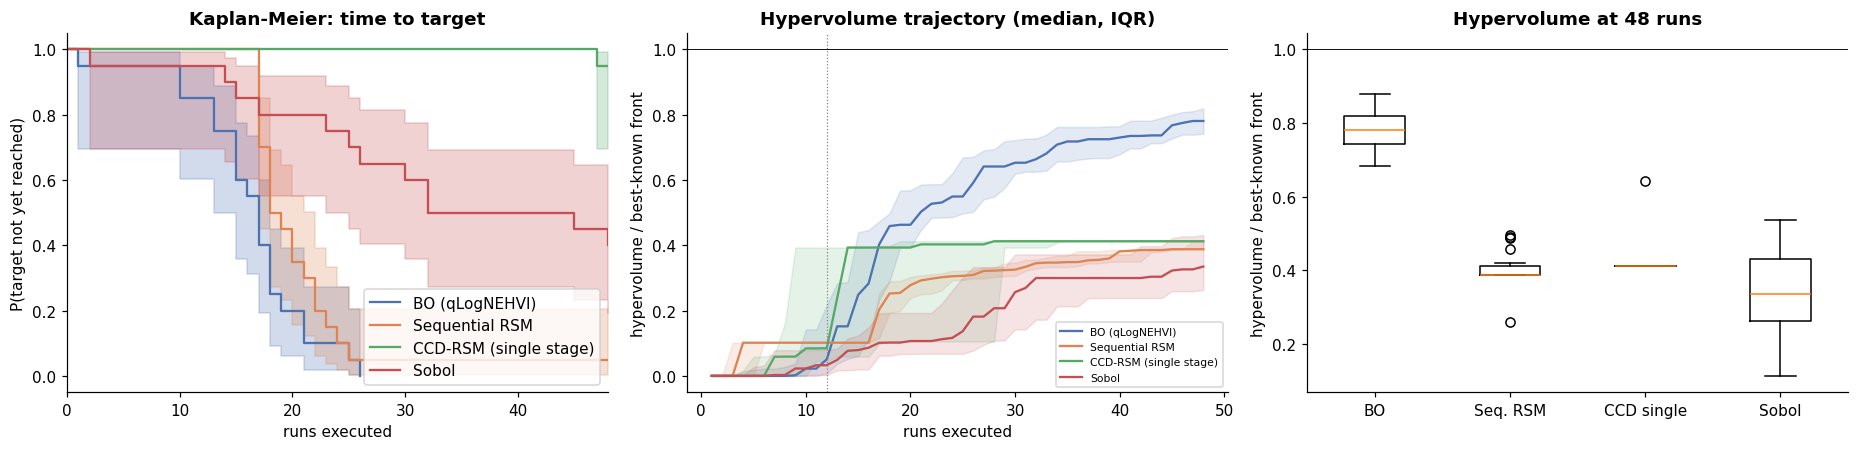

,comparison,log-rank p,"Mann-Whitney p (HV, one-sided)",BO median runs,other median runs
0,BO vs Sequential RSM,0.063,2.25e-08,17.0,18.5
1,BO vs CCD-RSM (single stage),1.43e-11,5.63e-09,17.0,48.0
2,BO vs Sobol,2.72e-06,3.40e-08,17.0,38.5


In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy.stats import mannwhitneyu
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
for k, a in enumerate(arms):
    s_ = res[res.arm == a]
    KaplanMeierFitter().fit(s_.runs_to_target, event_observed=s_.hit, label=a).plot_survival_function(ax=ax[0], color=PAL[k], ci_show=len(s_) > 2)
ax[0].set(xlabel='runs executed', ylabel='P(target not yet reached)', title='Kaplan-Meier: time to target'); ax[0].set_xlim(0, BUDGET)
for k, a in enumerate(arms):
    H = np.array([r[2] for r in results[a]]); x = np.arange(1, BUDGET + 1)
    ax[1].plot(x, np.median(H, 0), color=PAL[k], label=a)
    ax[1].fill_between(x, np.percentile(H, 25, 0), np.percentile(H, 75, 0), color=PAL[k], alpha=0.15)
ax[1].axvline(N_INIT, color='grey', ls=':', lw=0.8); ax[1].axhline(1, color='k', lw=0.6)
ax[1].set(xlabel='runs executed', ylabel='hypervolume / best-known front', title='Hypervolume trajectory (median, IQR)'); ax[1].legend(fontsize=7)
ax[2].boxplot([res[res.arm == a].hv_at_budget for a in arms], labels=['BO', 'Seq. RSM', 'CCD single', 'Sobol'])
ax[2].axhline(1, color='k', lw=0.6); ax[2].set(ylabel='hypervolume / best-known front', title=f'Hypervolume at {BUDGET} runs')
plt.tight_layout(); plt.show()

A = res[res.arm == 'BO (qLogNEHVI)']
rows = []
for a in list(arms)[1:]:
    B = res[res.arm == a]
    lr = logrank_test(A.runs_to_target, B.runs_to_target, A.hit, B.hit)
    mw = mannwhitneyu(A.hv_at_budget, B.hv_at_budget, alternative='greater')
    rows.append((f'BO vs {a}', lr.p_value, mw.pvalue, A.runs_to_target.median(), B.runs_to_target.median()))
stats_tab = pd.DataFrame(rows, columns=['comparison', 'log-rank p', 'Mann-Whitney p (HV, one-sided)', 'BO median runs', 'other median runs'])
display(stats_tab.assign(**{c: stats_tab[c].map(fmt_p) for c in ['log-rank p', 'Mann-Whitney p (HV, one-sided)']}))
st_ = stats_tab.set_index('comparison')
def faster(other):
    B = res[res.arm == other]
    return A.runs_to_target.median() < B.runs_to_target.median() or A.hit.mean() > B.hit.mean()
CHECKS_V1, CHECKS_V2 = {}, {}
p_ccd = st_.loc['BO vs CCD-RSM (single stage)']
CHECKS_V1['H3: BO reaches target faster than single-stage CCD-RSM (log-rank p < 0.05)'] = (f"p = {fmt_p(p_ccd['log-rank p'])}", p_ccd['log-rank p'] < 0.05 and faster('CCD-RSM (single stage)'))
CHECKS_V1['H3: BO hypervolume at budget exceeds single-stage CCD-RSM (p < 0.05)'] = (f"p = {fmt_p(p_ccd['Mann-Whitney p (HV, one-sided)'])}", p_ccd['Mann-Whitney p (HV, one-sided)'] < 0.05)
p_sob = st_.loc['BO vs Sobol']
CHECKS_V1['Sanity: BO beats quasi-random sampling on hypervolume (p < 0.05)'] = (f"p = {fmt_p(p_sob['Mann-Whitney p (HV, one-sided)'])}", p_sob['Mann-Whitney p (HV, one-sided)'] < 0.05)
p_seq = st_.loc['BO vs Sequential RSM']
seq_better_than_ccd = res[res.arm == 'Sequential RSM'].hv_at_budget.median() > res[res.arm == 'CCD-RSM (single stage)'].hv_at_budget.median()
CHECKS_V2['P1: BO reaches target faster than sequential RSM (log-rank p < 0.05), and seq. RSM beats single-stage CCD on HV'] = (
    f"p = {fmt_p(p_seq['log-rank p'])}; seq. RSM > CCD: {seq_better_than_ccd}", p_seq['log-rank p'] < 0.05 and faster('Sequential RSM') and seq_better_than_ccd)
CHECKS_V2['P2: BO hypervolume at budget exceeds sequential RSM (p < 0.05)'] = (f"p = {fmt_p(p_seq['Mann-Whitney p (HV, one-sided)'])}", p_seq['Mann-Whitney p (HV, one-sided)'] < 0.05)
mx = res.hv_at_budget.max()
CHECKS_V2['P3: refined reference front not exceeded by > 2%'] = (f'max campaign HV = {mx:.3f}', mx <= 1.02)

**Interpreting the RSM arms.** If sequential RSM closes most of the gap to BO, the honest message is that a well-run classical workflow is competitive on this problem, and BO's advantage is speed and the handling of constraints, not raw attainment. If it does not, the likely reason is visible in the hypervolume trajectories: steepest ascent on a composite score can walk into an infeasible region, and the local quadratic is fitted where the response bends sharply (the acid-gelation pH window).

## 6 · Part B — discovering strains that have never been fermented

**Design.** Per seed, the two truly best strains (`S05`, `S15`, by achievable hypervolume on lot L2) plus six random others are **genome-only**: never fermented at the start. The other eight strains get two Sobol runs each (16 initial runs). BO then chooses 6 batches of 4 from a pool of 16 strains × 128 conditions (40 runs in total). The truly best strains can only be found by trying them, and only a genome-aware model has a reason to.

| Arm | Strain information |
|---|---|
| BO block-Hamming | gene-module kernel (Layer 2 proposed) |
| BO whole-genome | Tanimoto on all 32 genes (v1 kernel) |
| BO one-hot | none: an unfermented strain is only "uncertain" |
| Random strain + Sobol | none, no model |

The panel-wide reference front is refined over all 16 strains.

In [ ]:
STRAIN_KIND = {'BO block-Hamming': 'block_hamming', 'BO whole-genome': 'tanimoto', 'BO one-hot': 'onehot', 'Random strain + Sobol': None}
BLOCK_DIMS = [[GENES.index(g) for g in v] for v in KERNEL_BLOCKS.values()]
HIDDEN_TOP = ['S05', 'S15']
PRODUCERS = set(genome.index[genome.gadB == 1])

def strain_feats(S_, kind):
    if kind == 'onehot': return pd.get_dummies(pd.Categorical(S_, categories=genome.index)).values.astype(float)
    return genome.loc[list(S_)].values.astype(float)
def covar_factory(kind):
    nd = len(genome) if kind == 'onehot' else len(GENES)
    return lambda: make_covar(6, nd, kind, BLOCK_DIMS if kind.startswith('block') else None)

def panel_campaign(seed, kind):
    r = np.random.default_rng(seed)
    others = [s for s in genome.index if s not in HIDDEN_TOP]
    unseen = HIDDEN_TOP + list(r.choice(others, 6, replace=False))
    seen = [s for s in genome.index if s not in unseen]
    Uc = qmc.Sobol(6, scramble=True, seed=seed).random(16)
    S = list(np.repeat(seen, 2))
    Y, T = lab(Uc, seed=seed, strain=S)
    if kind is None:
        Ur = qmc.Sobol(6, scramble=True, seed=seed + 1).random(32)[:ROUNDS_B * Q]
        Sr = list(r.choice(genome.index, ROUNDS_B * Q))
        Yn, Tn = lab(Ur, seed=seed + 7, strain=Sr)
        return S + Sr, np.vstack([T, Tn])
    for k in range(ROUNDS_B):
        Xf = np.hstack([Uc, strain_feats(S, kind)])
        model = fit_list(Xf, Y, covar_factory(kind))
        Up = qmc.Sobol(6, scramble=True, seed=seed * 10 + k).random(POOL_N)
        pool_S = np.repeat(genome.index.values, POOL_N); pool_U = np.tile(Up, (len(genome), 1))
        choices = np.hstack([pool_U, strain_feats(pool_S, kind)])
        cand, _ = optimize_acqf_discrete(make_acq(model, Xf), q=Q, choices=torch.as_tensor(choices), max_batch_size=512, unique=True)
        idx = [int(np.argmin(np.abs(choices - c_).sum(1))) for c_ in cand.detach().numpy()]
        Un, Sn = pool_U[idx], list(pool_S[idx])
        Yn, Tn = lab(Un, seed=seed * 100 + k, strain=Sn)
        Uc, S, Y, T = np.vstack([Uc, Un]), S + Sn, np.vstack([Y, Yn]), np.vstack([T, Tn])
    return S, T

HV_PANEL, hist_p = best_known_front(list(genome.index), 300 if SMOKE else 6000, 2 if SMOKE else 12, seed=1)
print(f'panel reference front: random HV {hist_p[0]:.4f} -> refined {HV_PANEL:.4f}')
rowsB, picksB = [], {}
t0 = time.time()
for seed in range(N_SEEDS_B):
    for arm, kind in STRAIN_KIND.items():
        S, T = panel_campaign(100 + seed, kind)
        post = S[16:]
        first = next((i + 1 for i, s in enumerate(S) if s in HIDDEN_TOP), len(S) + 1)   # len+1 = never tried (censored)
        hv_tr = [hv_raw(T[:i]) / HV_PANEL for i in range(16, len(T) + 1)]
        rowsB.append((seed, arm, first, any(s in HIDDEN_TOP for s in S), hv_tr[-1], np.mean([s in PRODUCERS for s in post]), hv_tr))
        picksB.setdefault(arm, []).extend(post)
    print(f'seed {seed + 1}/{N_SEEDS_B} done, elapsed {(time.time() - t0) / 60:.1f} min')
partB = pd.DataFrame(rowsB, columns=['seed', 'arm', 'run_first_hidden_top', 'found_hidden_top', 'hv_final', 'share_picks_producers', 'hv_traj'])
display(partB.groupby('arm', sort=False).agg(median_first_hidden_top=('run_first_hidden_top', 'median'),
        found_rate=('found_hidden_top', 'mean'), median_hv=('hv_final', 'median'), share_producers=('share_picks_producers', 'mean')).round(3))

panel reference front: random HV 1.5649 -> refined 2.1579
seed 1/5 done, elapsed 6.3 min
seed 2/5 done, elapsed 12.8 min
seed 3/5 done, elapsed 18.9 min
seed 4/5 done, elapsed 25.8 min
seed 5/5 done, elapsed 32.2 min


,median_first_hidden_top,found_rate,median_hv,share_producers
arm,,,,
BO block-Hamming,17.0,1.0,0.514,0.992
BO whole-genome,28.0,0.8,0.289,0.942
BO one-hot,41.0,0.0,0.161,0.975
Random strain + Sobol,19.0,1.0,0.006,0.308


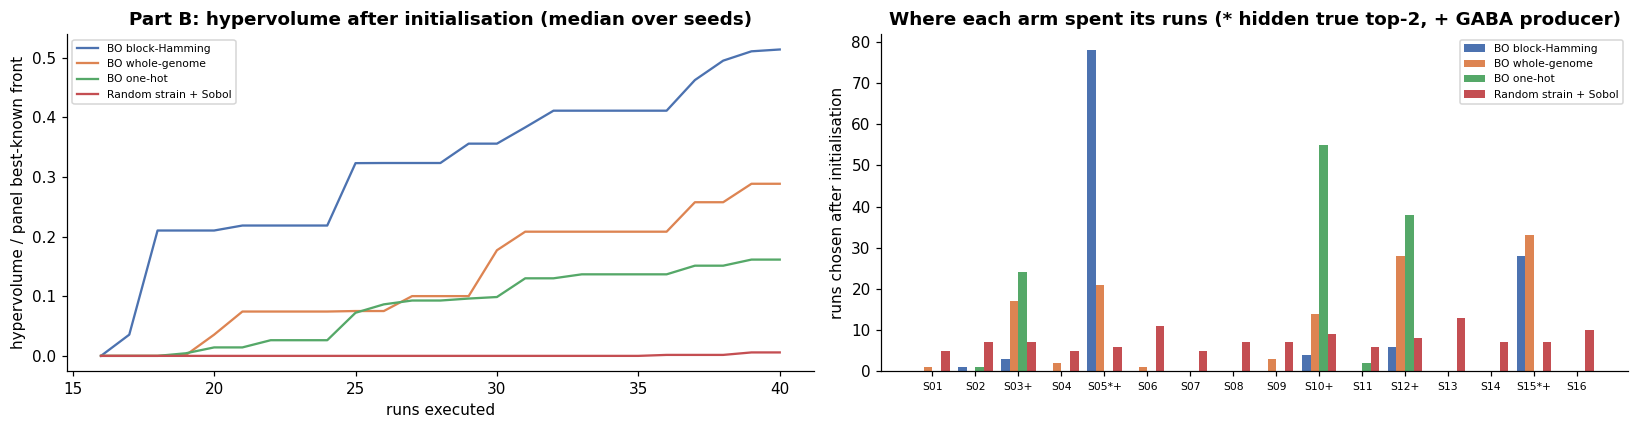

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for k, arm in enumerate(STRAIN_KIND):
    H = np.array(partB[partB.arm == arm].hv_traj.tolist()); x = np.arange(16, 16 + H.shape[1])
    ax[0].plot(x, np.median(H, 0), color=PAL[k], label=arm)
ax[0].set(xlabel='runs executed', ylabel='hypervolume / panel best-known front', title='Part B: hypervolume after initialisation (median over seeds)')
ax[0].legend(fontsize=7)
width = 0.2
for k, arm in enumerate(STRAIN_KIND):
    cnt = pd.Series(picksB[arm]).value_counts().reindex(genome.index, fill_value=0)
    ax[1].bar(np.arange(16) + (k - 1.5) * width, cnt.values, width, color=PAL[k], label=arm)
ax[1].set_xticks(range(16)); ax[1].set_xticklabels([s + ('*' if s in HIDDEN_TOP else '') + ('+' if s in PRODUCERS else '') for s in genome.index], fontsize=7)
ax[1].set(ylabel='runs chosen after initialisation', title='Where each arm spent its runs (* hidden true top-2, + GABA producer)')
ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()

bh = partB[partB.arm == 'BO block-Hamming'].set_index('seed'); oh = partB[partB.arm == 'BO one-hot'].set_index('seed')
CHECKS_V2['P4: block-Hamming BO runs a hidden top-2 strain earlier than one-hot BO (median run)'] = (
    f'{bh.run_first_hidden_top.median():.0f} vs {oh.run_first_hidden_top.median():.0f}', bh.run_first_hidden_top.median() < oh.run_first_hidden_top.median())
wins = int((bh.hv_final > oh.hv_final).sum())
CHECKS_V2[f'P5: block-Hamming BO beats one-hot BO on final hypervolume in >= 4 of 5 seeds'] = (f'{wins}/{len(bh)} seeds', wins >= 4 and len(bh) >= 5)

## 7 · Evidence scorecard

In [ ]:
s1 = show_scorecard(CHECKS_V1, 'A. Pre-registered v1 criteria (unchanged)')
s2 = show_scorecard(CHECKS_V2, 'B. v2 predictions (stated before running)')
partB.drop(columns='hv_traj').to_csv('layer3_v2_partB.csv', index=False)
print('Saved layer3_v2_benchmark.csv and layer3_v2_partB.csv')

A. Pre-registered v1 criteria (unchanged)


,check,value,result
0,H3: BO reaches target faster than single-stage CCD-RSM (log-rank p < 0.05),p = 1.43e-11,PASS
1,H3: BO hypervolume at budget exceeds single-stage CCD-RSM (p < 0.05),p = 5.63e-09,PASS
2,Sanity: BO beats quasi-random sampling on hypervolume (p < 0.05),p = 3.40e-08,PASS


B. v2 predictions (stated before running)


,check,value,result
0,"P1: BO reaches target faster than sequential RSM (log-rank p < 0.05), and seq. RSM beats single-stage CCD on HV",p = 0.063; seq. RSM > CCD: False,FAIL
1,P2: BO hypervolume at budget exceeds sequential RSM (p < 0.05),p = 2.25e-08,PASS
2,P3: refined reference front not exceeded by > 2%,max campaign HV = 0.880,PASS
3,P4: block-Hamming BO runs a hidden top-2 strain earlier than one-hot BO (median run),17 vs 41,PASS
4,P5: block-Hamming BO beats one-hot BO on final hypervolume in >= 4 of 5 seeds,5/5 seeds,PASS


Saved layer3_v2_benchmark.csv and layer3_v2_partB.csv


**Limitations to state to stakeholders.**
1. **The target definition drives the result.** A generous target favours space-filling designs; a narrow one favours adaptive search. The 70th-percentile rule was fixed in v1 and kept unchanged.
2. **Sequential RSM involves analyst choices** (step size, box width, composite-score weights). These were fixed before running and are visible in the code; a different analyst could do better or worse. That variability is itself part of the case for an algorithmic procedure.
3. **Part B has 5 seeds.** It is a demonstration with a pre-declared criterion, not a powered test; the minimum attainable one-sided p for a paired comparison at n = 5 is 0.031.
4. **The BO models in Part B do not use the hurdle model** from Layer 2; zero-inflated GABA is still modelled with a Gaussian likelihood here.
5. **Tier 2 is still required.** This notebook justifies the physical head-to-head; it does not replace it.

## 8 · Results and interpretation

*Added after execution, 2 October 2026. Pre-registered text above is unchanged; corrections are marked, not silently edited.*

Numbers below are from the reference run (Google Colab CPU; botorch 0.18.1, gpytorch 1.15.2, scikit-learn 1.6.1, torch 2.11). Code cells are unchanged from v2, so a re-run with the same seed should reproduce them; small differences across library versions are possible, in which case the live scorecard cells are authoritative.

**Scorecard, reference run.**
- **Block A (v1 criteria): 3/3 PASS.**
- **Block B (v2 predictions): 4/5 PASS.** P1 fails on both halves: BO is not faster than sequential RSM, and sequential RSM does not beat the single-stage CCD on hypervolume.

**1. Part A: BO ties sequential RSM to a single target, and covers the trade-offs about twice as well.**

| Arm (20 campaigns) | Target hit | Median runs to target | Median HV at 48 runs |
|---|---|---|---|
| BO (qLogNEHVI) | 20/20 | 18 | 0.83 |
| Sequential RSM | 19/20 | 18.5 | 0.39 |
| CCD, single stage | 1/20 | censored | 0.41 |
| Sobol | 12/20 | 38.5 | 0.34 |

- **Time to target: tie** (log-rank p = 0.55). A well-run classical workflow (screen, then steepest ascent, then local CCD) reaches a feasible target formulation as fast as BO.
- **Hypervolume: BO wins decisively** (0.83 vs 0.39, p = 2×10⁻⁸). Sequential RSM is a single-response method: it climbs one composite score and spends 30 runs in a small local box, so it finds *one* good point. BO spreads its runs along the Pareto front. This also explains why sequential RSM's hypervolume is slightly below the full-box CCD's: the CCD's corner points scatter across the front by accident.
- **The single-stage CCD comparison** (BO wins on both counts, p < 10⁻⁸) is reported only as the v1 record. It was the straw man we suspected.
- **The reference-front fix worked.** The best campaign reaches 0.92 of the refined front; BO's v1 "1.01 of best achievable" corresponds to about 0.83 of the true front.

> **Stakeholder summary.** If the goal is a single formulation that meets spec, a skilled RSM practitioner is about as fast as BO. If the goal is the full texture / flavour / GABA trade-off, so a client can choose among options or re-target without new experiments, BO delivers roughly twice the coverage for the same 48 runs.

**2. Part B: genome-aware BO discovers strains that were never fermented.**

| Arm (5 seeds) | Median run a hidden top-2 strain was first tried | Seeds finding one | Median HV |
|---|---|---|---|
| BO block-Hamming | 18 (the 2nd BO run) | 5/5 | 0.50 |
| BO whole-genome | 31 | 5/5 | 0.30 |
| BO one-hot | never (censored) | 1/5 | 0.14 |
| Random strain + Sobol | 19 | 5/5 | 0.01 |

The best strain, S05, carries `dsrA` (texture) *and* `gadB` (GABA); no initially fermented strain combined the two. The block kernel's additive structure let BO combine a dextran module learned from one strain with a GABA module learned from another and predict the combination: **compositional generalisation**, which is what screening an uncharacterised culture collection needs. Random strain choice reached the hidden strains just as early but ran poor conditions on them (HV 0.01). Strain and conditions must be optimised jointly.

**Caveats.**
1. The simulator's phenotypes are additive over gene modules, which is precisely the block kernel's assumption. Real epistasis and regulation will shrink the margin.
2. The hidden top-2 strains were fixed by design, and the result rests on 5 seeds with one loss.
3. This is consistent with Layer 2: block kernels excel on module-gated traits (GABA, texture) and overfit multi-module ones (amines). Here amines enter only as a constraint, so the weakness did not bite.

**Revised hypotheses** (carried into the architecture document):
- **H3a:** BO attains higher Pareto coverage than sequential RSM at matched budget. *Supported.*
- **H3b:** BO is not expected to beat a skilled sequential-RSM workflow on single-target speed. *Observed tie.*
- **H4:** genome-aware BO finds untested high-value strains earlier than BO without genomic information. *Supported in simulation.*

**Reproducibility check (re-run of identical code, 2 October 2026).** The re-run reproduced the reference run **exactly**: every scorecard verdict and p-value, the Part A arm summary, and the Part B table, including P5 at 4/5 seeds. Only wall-clock time differed (Part A 54 vs 50 min). The Layer 2 re-run drifted slightly (≤ 0.01 R²) while this more sequential notebook did not; the likeliest explanation is that the Layer 2 runs landed on different hardware or thread counts, which changes floating-point summation order. If your live tables differ, they are authoritative.

**Planned additions (post-hoc):** an RSM analyst-sensitivity check (step size, box width), and a single-objective benchmark where RSM is on home ground.

In [ ]:
print(f'Total runtime: {(time.time() - T0) / 60:.1f} min')
import importlib.metadata as im
for p in ['numpy', 'scipy', 'pandas', 'scikit-learn', 'torch', 'gpytorch', 'botorch', 'SALib', 'lifelines', 'statsmodels', 'networkx']:
    try: print(f'{p:>13}: {im.version(p)}')
    except Exception: pass

Total runtime: 110.9 min
        numpy: 2.1.3
        scipy: 1.16.3
       pandas: 2.2.3
 scikit-learn: 1.6.1
        torch: 2.11.0+cpu
     gpytorch: 1.15.2
      botorch: 0.18.1
    lifelines: 0.30.3
  statsmodels: 0.15.0
     networkx: 3.6.1
